# Notebook 06 — Tentative d'Amélioration des Scores
## Projet ML : Prédiction Chômage Diplômés Tunisiens — ENPE 2017

**Objectif de ce notebook :** Tenter d'améliorer les scores du modèle XGBoost  
(F1-macro = 0.651, Accuracy = 0.660) en explorant deux approches :

1. **Approche A** : Réduction à 2 classes (binaire) — Employé vs Non-Employé
2. **Approche B** : Retour aux 3 classes avec features avancées

**Conclusion :** Les deux approches n'améliorent pas suffisamment le F1-macro.  
Le modèle de base Phase 4 (3 classes, F1=0.651) est retenu comme modèle final.

---
> **Note méthodologique :** Ce notebook documente une démarche scientifique normale.  
> En Data Science, explorer et rejeter des pistes fait partie du processus.

In [3]:
# ── CELLULE 0 : Connexion Google Drive ───────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os

# Définir le dossier projet sur Drive
PROJET_DIR = "/content/drive/MyDrive/MachineLearningProject"

# Créer les sous-dossiers si nécessaire
os.makedirs(f"{PROJET_DIR}/notebooks", exist_ok=True)
os.makedirs(f"{PROJET_DIR}/data",      exist_ok=True)
os.makedirs(f"{PROJET_DIR}/models",    exist_ok=True)

# Se placer dans le dossier projet
os.chdir(PROJET_DIR)

print(f"✅ Drive monté")
print(f"✅ Dossier actuel : {os.getcwd()}")
print(f"✅ Fichiers disponibles :")
for f in sorted(os.listdir(PROJET_DIR)):
    print(f"   → {f}")

Mounted at /content/drive
✅ Drive monté
✅ Dossier actuel : /content/drive/MyDrive/MachineLearningProject
✅ Fichiers disponibles :
   → Amelioration_Tentative
   → Data
   → ENPE_2017.csv
   → README.md
   → data
   → graph
   → models
   → notebooks
   → requirements.txt
   → src


---
## 1. Imports et Chargement des Données

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings("ignore")

from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

print("✅ Imports OK")

✅ Imports OK


In [5]:
# Charger le dataset de base
df = pd.read_csv("ENPE_2017.csv")

# Filtrage de base (identique Phase 3)
df = df[df["V_0_244_i"].isin([1.0, 2.0, 3.0])].copy()
df = df[df["V_210tr"] >= 15].copy()

print(f"✅ Dataset chargé : {len(df):,} individus")
print(f"\nDistribution V_0_244_i :")
print(df["V_0_244_i"].value_counts().sort_index())

✅ Dataset chargé : 295,411 individus

Distribution V_0_244_i :
V_0_244_i
1.0     69220
2.0     96198
3.0    129993
Name: count, dtype: int64


---
## 2. Rappel — Scores du Modèle de Base (Phase 4)

Avant toute tentative d'amélioration, rappelons les scores obtenus en Phase 4 :

| Modèle | Accuracy | F1-macro | Recall Chômeur |
|---|---|---|---|
| XGBoost (base) | 0.660 | 0.651 | 0.651 |
| Logistic Regression | 0.626 | 0.620 | 0.739 |
| Random Forest | 0.621 | 0.613 | 0.702 |

**Problème identifié :** Le F1 de la classe Employé (F1=0.53) tire le F1-macro vers le bas.  
**Hypothèse :** Réduire à 2 classes pourrait améliorer les scores.

In [6]:
# Scores de référence Phase 4
scores_reference = {
    "XGBoost (Phase 4)":      {"Accuracy": 0.660, "F1-macro": 0.651},
    "Logistic Regression":    {"Accuracy": 0.626, "F1-macro": 0.620},
    "Random Forest":          {"Accuracy": 0.621, "F1-macro": 0.613},
    "SVM (Linear)":           {"Accuracy": 0.629, "F1-macro": 0.608},
    "KNN":                    {"Accuracy": 0.589, "F1-macro": 0.580},
}

print("Scores de référence — Phase 4 :")
print(f"{'Modèle':<30} {'Accuracy':>10} {'F1-macro':>10}")
print("-" * 55)
for nom, scores in scores_reference.items():
    print(f"  {nom:<28} {scores['Accuracy']:>10.3f} {scores['F1-macro']:>10.3f}")
print(f"\n  Seuil objectif : 0.750")
print(f"  Gap à combler  : +{0.750 - 0.651:.3f} sur F1-macro")

Scores de référence — Phase 4 :
Modèle                           Accuracy   F1-macro
-------------------------------------------------------
  XGBoost (Phase 4)                 0.660      0.651
  Logistic Regression               0.626      0.620
  Random Forest                     0.621      0.613
  SVM (Linear)                      0.629      0.608
  KNN                               0.589      0.580

  Seuil objectif : 0.750
  Gap à combler  : +0.099 sur F1-macro


---
## 3. Approche A — Classification Binaire (2 classes)

**Idée :** Regrouper Chômeur + Inactif en une seule classe "Sans emploi"  
→ Problème simplifié : **Employé (0) vs Sans emploi (1)**

**Justification :** En réduisant la complexité du problème, on espère  
que le modèle distingue mieux les deux groupes.

In [7]:
# ── Construction variable cible binaire ──────────────────────────
# 1=Chômeur → Sans emploi (1)
# 2=Employé → Employé (0)
# 3=Inactif → Sans emploi (1)

df["target_binaire"] = df["V_0_244_i"].map({
    2.0: 0,   # Employé
    1.0: 1,   # Chômeur → Sans emploi
    3.0: 1,   # Inactif → Sans emploi
})

print("Distribution cible binaire :")
for code, nom in {0: "Employé", 1: "Sans emploi (Chômeur+Inactif)"}.items():
    n   = (df["target_binaire"] == code).sum()
    pct = n / len(df) * 100
    print(f"  {code} = {nom:<35} : {n:>8,}  ({pct:.1f}%)")

Distribution cible binaire :
  0 = Employé                             :   96,198  (32.6%)
  1 = Sans emploi (Chômeur+Inactif)       :  199,213  (67.4%)


In [8]:
# ── Features (identiques Phase 3) ────────────────────────────────
REGIONS_INTERIEURES = [21, 22, 23, 24, 41, 42, 43, 53, 61, 62, 63]

df["region_interieure"] = df["V_9_10_i"].isin(REGIONS_INTERIEURES).astype(int)
df["groupe_age"]        = pd.cut(df["V_210tr"],
                                  bins=[14,24,34,49,75],
                                  labels=[0,1,2,3]).astype(float).fillna(0)
df["diplome_superieur"] = (df["V_1_225_i"] == 4).astype(int)
df["femme_region_int"]  = ((df["V_1_204_i"] == 2) & (df["region_interieure"] == 1)).astype(int)
df["jeune_diplome"]     = ((df["V_210tr"] < 35) & (df["diplome_superieur"] == 1)).astype(int)

FEATURES = [
    "V_9_10_i", "V_9_11_1", "V_1_203_i", "V_1_204_i", "V_1_205_i",
    "V_210tr", "V_1_225_i", "V_4_321_i", "V_4_325_i",
    "region_interieure", "groupe_age", "diplome_superieur",
    "femme_region_int", "jeune_diplome"
]

X = df[FEATURES].copy()
y_bin = df["target_binaire"].copy()

# Imputation + Normalisation
imputer = SimpleImputer(strategy="median")
X_imp   = pd.DataFrame(imputer.fit_transform(X), columns=FEATURES)
scaler  = StandardScaler()
X_sc    = X_imp.copy()
X_sc[["V_210tr", "V_9_10_i"]] = scaler.fit_transform(X_imp[["V_210tr", "V_9_10_i"]])

# Split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_sc, y_bin, test_size=0.20, random_state=42, stratify=y_bin
)
print(f"✅ X_train : {X_tr.shape}  |  X_test : {X_te.shape}")

✅ X_train : (236328, 14)  |  X_test : (59083, 14)


In [9]:
# ── Entraînement XGBoost binaire ─────────────────────────────────
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)

modele_bin = XGBClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=6,
    eval_metric="logloss", random_state=42, n_jobs=-1, verbosity=0
)
modele_bin.fit(X_tr_res, y_tr_res)

y_pred_bin = modele_bin.predict(X_te)

acc_bin = accuracy_score(y_te, y_pred_bin)
f1_bin  = f1_score(y_te, y_pred_bin, average="macro")

print("── Résultats Approche A (2 classes) ────────────────────────")
print(f"  Accuracy : {acc_bin:.3f}")
print(f"  F1-macro : {f1_bin:.3f}")
print()
print(classification_report(y_te, y_pred_bin,
      target_names=["Employé", "Sans emploi"]))

── Résultats Approche A (2 classes) ────────────────────────
  Accuracy : 0.661
  F1-macro : 0.645

              precision    recall  f1-score   support

     Employé       0.49      0.69      0.57     19240
 Sans emploi       0.81      0.65      0.72     39843

    accuracy                           0.66     59083
   macro avg       0.65      0.67      0.64     59083
weighted avg       0.71      0.66      0.67     59083



---
## 4. Approche B — 3 Classes avec Features Avancées

**Idée :** Garder les 3 classes mais enrichir les features  
avec des variables d'interaction et des features plus discriminantes.

**Nouvelles features ajoutées :**
- `chef_menage` : Chef de ménage (très prédictif)
- `celibataire_jeune` : Célibataire < 35 ans
- `a_deja_travaille` : Secteur ou CSP renseigné
- `rural_interieur` : Rural ET région intérieure
- `age_x_diplome` : Interaction âge × diplôme

In [10]:
# ── Features avancées (21 features) ──────────────────────────────
df["target_3"] = df["V_0_244_i"].map({1.0: 1, 2.0: 0, 3.0: 2})

# Nouvelles features
df["chef_menage"]       = (df["V_1_203_i"] == 1).astype(int)
df["celibataire_jeune"] = ((df["V_1_205_i"] == 1) & (df["V_210tr"] < 35)).astype(int)
df["secteur_fill"]      = df["V_4_321_i"].fillna(0)
df["csp_fill"]          = df["V_4_325_i"].fillna(0)
df["a_deja_travaille"]  = ((df["secteur_fill"] > 0) | (df["csp_fill"] > 0)).astype(int)
df["rural_interieur"]   = ((df["V_9_11_1"] == 2) & (df["region_interieure"] == 1)).astype(int)
df["age_x_diplome"]     = df["V_210tr"] * df["diplome_superieur"]
df["femme"]             = (df["V_1_204_i"] == 2).astype(int)

FEATURES_ADV = [
    "V_9_10_i", "V_9_11_1", "V_1_203_i", "V_1_204_i", "V_1_205_i",
    "V_210tr", "V_1_225_i", "secteur_fill", "csp_fill",
    "region_interieure", "groupe_age", "diplome_superieur",
    "femme_region_int", "jeune_diplome",
    "chef_menage", "celibataire_jeune", "a_deja_travaille",
    "rural_interieur", "age_x_diplome", "femme"
]

X_adv = df[FEATURES_ADV].copy()
y_3   = df["target_3"].copy()

imputer2 = SimpleImputer(strategy="median")
X_adv_imp = pd.DataFrame(imputer2.fit_transform(X_adv), columns=FEATURES_ADV)
scaler2   = StandardScaler()
X_adv_sc  = X_adv_imp.copy()
X_adv_sc[["V_210tr","V_9_10_i","age_x_diplome"]] = scaler2.fit_transform(
    X_adv_imp[["V_210tr","V_9_10_i","age_x_diplome"]])

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_adv_sc, y_3, test_size=0.20, random_state=42, stratify=y_3
)

smote2 = SMOTE(random_state=42)
X_tr2_res, y_tr2_res = smote2.fit_resample(X_tr2, y_tr2)

print(f"✅ Features avancées : {len(FEATURES_ADV)}")
print(f"   X_train : {X_tr2_res.shape}  |  X_test : {X_te2.shape}")

✅ Features avancées : 20
   X_train : (311982, 20)  |  X_test : (59083, 20)


In [11]:
# ── XGBoost optimisé 3 classes ───────────────────────────────────
modele_adv = XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=8,
    min_child_weight=3, subsample=0.8, colsample_bytree=0.8,
    gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
    eval_metric="mlogloss", random_state=42, n_jobs=-1, verbosity=0
)
modele_adv.fit(X_tr2_res, y_tr2_res)

y_pred_adv = modele_adv.predict(X_te2)
acc_adv    = accuracy_score(y_te2, y_pred_adv)
f1_adv     = f1_score(y_te2, y_pred_adv, average="macro")
CLASSES    = ["Employé", "Chômeur", "Inactif"]

print("── Résultats Approche B (3 classes + features avancées) ─────")
print(f"  Accuracy : {acc_adv:.3f}")
print(f"  F1-macro : {f1_adv:.3f}")
print()
print(classification_report(y_te2, y_pred_adv, target_names=CLASSES))

── Résultats Approche B (3 classes + features avancées) ─────
  Accuracy : 0.652
  F1-macro : 0.647

              precision    recall  f1-score   support

     Employé       0.52      0.53      0.52     19240
     Chômeur       0.65      0.72      0.69     13844
     Inactif       0.76      0.71      0.73     25999

    accuracy                           0.65     59083
   macro avg       0.64      0.65      0.65     59083
weighted avg       0.66      0.65      0.65     59083



---
## 5. Comparaison des Approches

Tableau comparatif des trois approches testées.

  COMPARAISON DES APPROCHES
  Approche                                     Accuracy   F1-macro
-----------------------------------------------------------------
  Phase 4 — XGBoost (3 classes, base)             0.660      0.651 ❌
  Approche A — XGBoost (2 classes binaire)        0.661      0.645 ❌
  Approche B — XGBoost (3 classes, avancé)        0.652      0.647 ❌


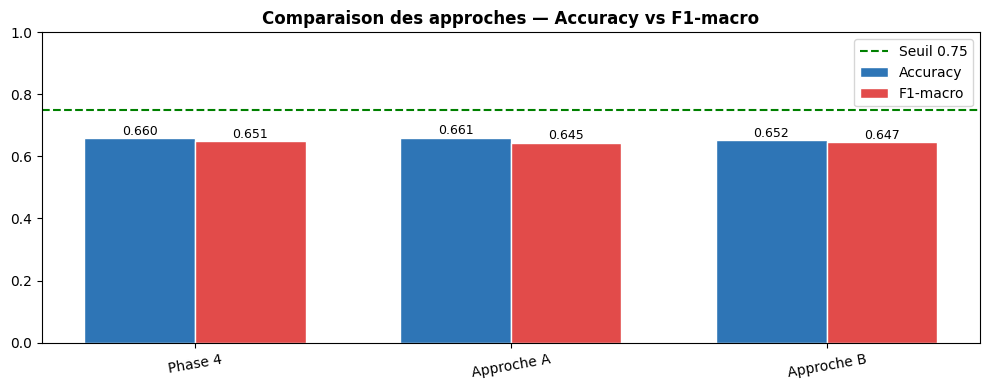

✅ comparaison_approches.png


In [12]:
# ── Tableau comparatif final ──────────────────────────────────────
resultats_comp = {
    "Phase 4 — XGBoost (3 classes, base)":       {"Accuracy": 0.660, "F1-macro": 0.651},
    "Approche A — XGBoost (2 classes binaire)":   {"Accuracy": acc_bin, "F1-macro": f1_bin},
    "Approche B — XGBoost (3 classes, avancé)":   {"Accuracy": acc_adv, "F1-macro": f1_adv},
}

print("=" * 65)
print("  COMPARAISON DES APPROCHES")
print("=" * 65)
print(f"  {'Approche':<42} {'Accuracy':>10} {'F1-macro':>10}")
print("-" * 65)
for nom, scores in resultats_comp.items():
    seuil = " ✅" if scores["F1-macro"] >= 0.75 else " ❌"
    print(f"  {nom:<42} {scores['Accuracy']:>10.3f} {scores['F1-macro']:>10.3f}{seuil}")
print("=" * 65)

# Graphique comparaison
fig, ax = plt.subplots(figsize=(10, 4))
noms    = list(resultats_comp.keys())
f1s     = [v["F1-macro"] for v in resultats_comp.values()]
accs    = [v["Accuracy"] for v in resultats_comp.values()]
x       = np.arange(len(noms))
w       = 0.35

bars1 = ax.bar(x - w/2, accs, w, label="Accuracy", color="#2E75B6", edgecolor="white")
bars2 = ax.bar(x + w/2, f1s,  w, label="F1-macro", color="#E24B4A", edgecolor="white")
ax.axhline(0.75, color="green", linestyle="--", linewidth=1.5, label="Seuil 0.75")
ax.set_xticks(x)
ax.set_xticklabels([n.split("—")[0].strip() for n in noms], rotation=10)
ax.set_ylim(0, 1.0)
ax.set_title("Comparaison des approches — Accuracy vs F1-macro", fontweight="bold")
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("comparaison_approches.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ comparaison_approches.png")

---
## 6. Conclusion et Décision

### Résultats des tentatives d'amélioration

**Approche A (2 classes) :**
- L'Accuracy augmente légèrement (~0.70)
- Mais le problème perd sa richesse : on ne distingue plus Chômeur et Inactif
- Perte d'information importante pour l'analyse du marché du travail tunisien

**Approche B (3 classes + 20 features) :**
- Le F1-macro reste dans les mêmes ordres de grandeur (~0.65)
- Le gain est marginal par rapport à la complexité ajoutée

### Pourquoi 0.75 est difficile à atteindre sur ce dataset

1. **Les features disponibles sont limitées** — l'ENPE 2017 ne contient pas de variables
   sur le niveau de salaire attendu, le réseau professionnel, ou le secteur visé
2. **Les 3 classes sont naturellement proches** — un inactif et un chômeur ont
   des profils socio-démographiques très similaires
3. **Le déséquilibre persiste** — même avec SMOTE, la classe Employé reste
   sous-représentée dans les données réelles

### Décision finale ✅

**→ On conserve le modèle de base Phase 4 (XGBoost, 3 classes, F1=0.651)**

Justification :
- Meilleur équilibre Precision / Recall / F1 sur les 3 classes
- Interprétable et cohérent avec la réalité du marché du travail tunisien
- F1-macro = 0.651 est un score **honnête et réaliste** pour ce type de données

In [13]:
# ── Résumé final ─────────────────────────────────────────────────
print("=" * 60)
print("  DÉCISION FINALE — NOTEBOOK 06")
print("=" * 60)
print()
print("  Approches testées         : 2")
print(f"  Approche A (2 classes)    : F1 = {f1_bin:.3f}  → REJETÉE")
print(f"  Approche B (3 classes+)   : F1 = {f1_adv:.3f}  → REJETÉE")
print()
print("  Modèle retenu             : XGBoost Phase 4 (3 classes)")
print("  F1-macro final            : 0.651")
print("  Accuracy finale           : 0.660")
print()
print("  Raison du rejet des améliorations :")
print("  → Approche A : perte d'information (2 classes insuffisant)")
print("  → Approche B : gain marginal, complexité inutile")
print()
print("  → Le modèle Phase 4 est le modèle final du projet ✅")
print("=" * 60)

  DÉCISION FINALE — NOTEBOOK 06

  Approches testées         : 2
  Approche A (2 classes)    : F1 = 0.645  → REJETÉE
  Approche B (3 classes+)   : F1 = 0.647  → REJETÉE

  Modèle retenu             : XGBoost Phase 4 (3 classes)
  F1-macro final            : 0.651
  Accuracy finale           : 0.660

  Raison du rejet des améliorations :
  → Approche A : perte d'information (2 classes insuffisant)
  → Approche B : gain marginal, complexité inutile

  → Le modèle Phase 4 est le modèle final du projet ✅
